## Image Classification using SimpleViT (Vision Transformer)

This notebook implements an image classification pipeline using SimpleViT, a simplified Vision Transformer model, for classifying environmental microorganism images.

The workflow includes:

- Loading and preprocessing of denoised image datasets
- Applying image transformations and preparing train/validation splits
- Training a SimpleViT model from scratch or using pre-trained weights
- Evaluating the model using accuracy, F1-score, and confusion matrix
- Saving the trained model and visualizing key performance metrics



Epoch 1/30 | Train Loss: 3.1376 | Val Loss: 2.9169
Val Accuracy: 0.0536, Precision: 0.0536, Recall: 0.0536, F1: 0.0536
Best model saved!
Epoch 2/30 | Train Loss: 2.8952 | Val Loss: 2.7291
Val Accuracy: 0.1429, Precision: 0.1429, Recall: 0.1429, F1: 0.1429
Best model saved!
Epoch 3/30 | Train Loss: 2.7498 | Val Loss: 2.6736
Val Accuracy: 0.1429, Precision: 0.1429, Recall: 0.1429, F1: 0.1429
Best model saved!
Epoch 4/30 | Train Loss: 2.6890 | Val Loss: 2.6149
Val Accuracy: 0.1548, Precision: 0.1548, Recall: 0.1548, F1: 0.1548
Best model saved!
Epoch 5/30 | Train Loss: 2.6630 | Val Loss: 2.5710
Val Accuracy: 0.2202, Precision: 0.2202, Recall: 0.2202, F1: 0.2202
Best model saved!
Epoch 6/30 | Train Loss: 2.5812 | Val Loss: 2.4460
Val Accuracy: 0.2500, Precision: 0.2500, Recall: 0.2500, F1: 0.2500
Best model saved!
Epoch 7/30 | Train Loss: 2.5634 | Val Loss: 2.5397
Val Accuracy: 0.2619, Precision: 0.2619, Recall: 0.2619, F1: 0.2619
No improvement for 1 epoch(s)
Epoch 8/30 | Train Loss: 2.54

C:\Users\23771\AppData\Local\Temp\ipykernel_38092\1515326635.py:135: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("50_classification_Simple


Best Val Accuracy: 47.02%
Final F1-score: 0.4702


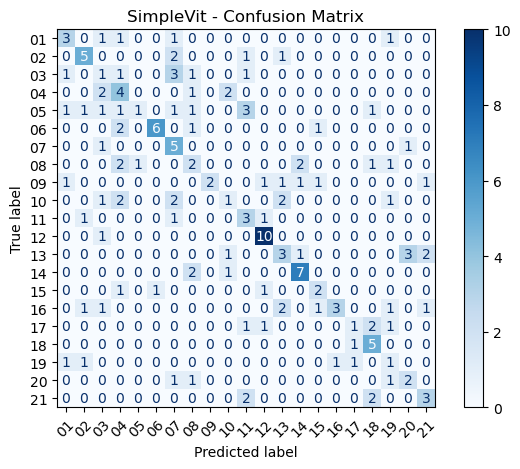

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
from torchmetrics import Accuracy, Precision, Recall, F1Score
from vit_pytorch import SimpleViT
from torch.optim.lr_scheduler import ReduceLROnPlateau
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from PIL import Image

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Parameters setting
image_size = 224
num_classes = 21
batch_size = 32
max_epochs = 30
early_stop_patience = 7


# Data preprocessing
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),  # 必须在 RandomErasing 之前转成 Tensor
    transforms.RandomErasing(p=0.3),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Loading datasets and dividing it into Train, validation and test.
dataset = datasets.ImageFolder("../../../task 2 - Image segmentation/U-Net++/EMDS5-Unetpp-DnCnn", transform=transform)
class_names = dataset.classes
train_size = int(0.7 * len(dataset))
val_size = int(0.2 * len(dataset))
test_size = len(dataset) - train_size - val_size
train_set, val_set, test_set = random_split(dataset, [train_size, val_size, test_size])
train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_set, batch_size=batch_size)
test_loader = DataLoader(test_set, batch_size=batch_size)

# Construct Vit model(enhance droup out)
model = SimpleViT(
    image_size = 224,
    patch_size = 16,
    num_classes = 21,
    dim = 256,
    depth = 4,
    heads = 4,
    mlp_dim = 512
).to(device)

# Optimizer and leaning rate modified
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=3e-4)
lr_scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

# Evaluation
metric_acc = Accuracy(task='multiclass', num_classes=num_classes).to(device)
metric_precision = Precision(task='multiclass', num_classes=num_classes).to(device)
metric_recall = Recall(task='multiclass', num_classes=num_classes).to(device)
metric_f1 = F1Score(task='multiclass', num_classes=num_classes).to(device)

# Training + Early Stopping
best_val_loss = float('inf')
no_improve_epochs = 0

for epoch in range(1, max_epochs+1):
    model.train()
    train_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    train_loss /= len(train_loader)

    # in validation
    model.eval()
    val_loss = 0
    metric_acc.reset()
    metric_precision.reset()
    metric_recall.reset()
    metric_f1.reset()

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)
            metric_acc.update(preds, labels)
            metric_precision.update(preds, labels)
            metric_recall.update(preds, labels)
            metric_f1.update(preds, labels)

    val_loss /= len(val_loader)
    val_acc = metric_acc.compute()
    val_prec = metric_precision.compute()
    val_rec = metric_recall.compute()
    val_f1 = metric_f1.compute()

    print(f"Epoch {epoch}/{max_epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")
    print(f"Val Accuracy: {val_acc:.4f}, Precision: {val_prec:.4f}, Recall: {val_rec:.4f}, F1: {val_f1:.4f}")

    # Update learning rate
    lr_scheduler.step(val_loss)

    # Early Stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_val_acc = val_acc.item()
        best_val_f1 = val_f1.item()
        no_improve_epochs = 0
        torch.save(model.state_dict(), "50_classification_Simple_vit_model.pth")
        print("Best model saved!")
    else:
        no_improve_epochs += 1
        print(f"No improvement for {no_improve_epochs} epoch(s)")
        if no_improve_epochs >= early_stop_patience:
            print("Early stopping triggered!")
            break

# loading the model
model.load_state_dict(torch.load("50_classification_Simple_vit_model.pth"))
model.eval()

# collect prediction
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Building confusion matrix
cm = confusion_matrix(all_labels, all_preds)

# visible confusion matrix
print(f"\nBest Val Accuracy: {best_val_acc * 100:.2f}%")
print(f"Final F1-score: {best_val_f1:.4f}")

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues, xticks_rotation=45, values_format='d')
plt.title("SimpleVit - Confusion Matrix")
plt.grid(False)
plt.tight_layout()
plt.show()

✅ Predicted class: 02


C:\Users\23771\AppData\Local\Temp\ipykernel_29668\3209011705.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("20_classification_Simple_v

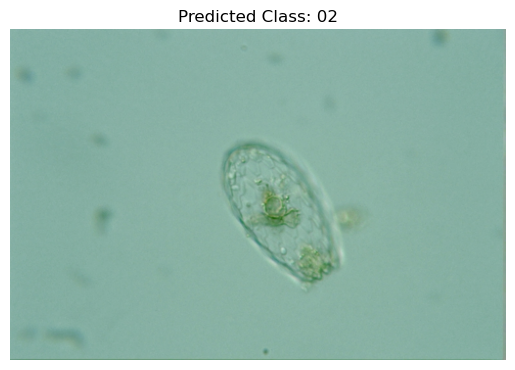

In [ ]:
#Testing model
# Loading the saved model
model.load_state_dict(torch.load("50_classification_Simple_vit_model.pth", map_location=device))
model.eval()

# Test a specific image
image_path = "EMDS-6/EMDS5-Original/07/EMDS5-g07-02.png"
image = Image.open(image_path).convert("RGB")
img_tensor = transform(image).unsqueeze(0).to(device)

with torch.no_grad():
    output = model(img_tensor)
    pred = torch.argmax(output, dim=1).item()

print(f"✅ Predicted class: {class_names[pred]}")
plt.imshow(image)
plt.title(f"Predicted Class: {class_names[pred]}")
plt.axis('off')
plt.show()
